# Microplastic Object Detection & Visualization

In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
annotations_path = "train/_annotations.csv"
df = pd.read_csv(annotations_path)

In [4]:
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,102,170,123,196
1,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,395,247,424,281
2,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,160,254,188,290
3,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,187,307,213,346
4,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,175,379,209,427


In [5]:
image_dir = "train"
sample_filename = df["filename"].iloc[0]
image_path = os.path.join(image_dir, sample_filename)

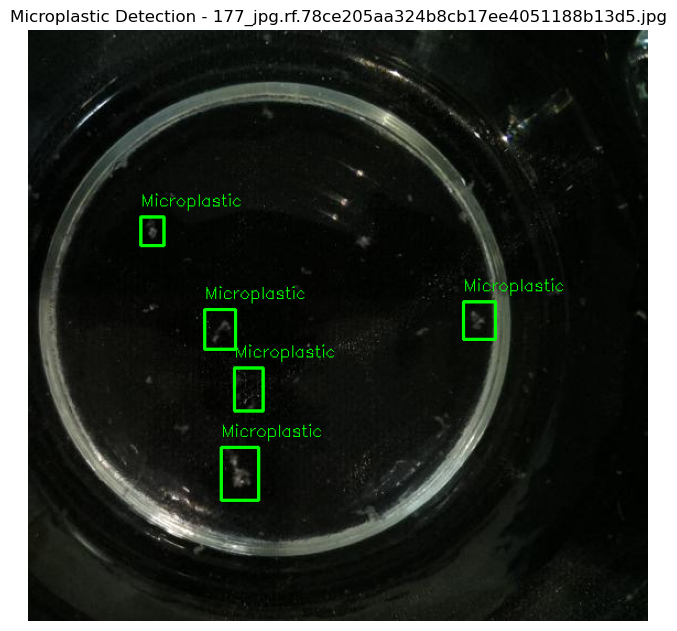

In [11]:
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = df[df["filename"] == sample_filename]

    for index, row in boxes.iterrows():
        xmin, ymin, xmax, ymax = (
            row["xmin"],
            row["ymin"],
            row["xmax"],
            row["ymax"],
        )
        cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(
            img_rgb,
            row["class"],
            (xmin, max(0, ymin - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Microplastic Detection - {sample_filename}")
    plt.show()
else:
    print(f"Image {sample_filename} not found in '{image_dir}' directory.")

In [9]:
object_counts = df["filename"].value_counts()
print(f"\nTotal unique images with annotations: {len(object_counts)}")
print(f"Average microplastics per image: {object_counts.mean():.2f}")


Total unique images with annotations: 577
Average microplastics per image: 9.40
